In [20]:
import numpy as np
import pyccl as ccl
from astropy.io import fits
import matplotlib.pyplot as plt

dataset = "/home/weichen/cosmo_practice/dataset_hsc_y3.fits"
with fits.open(dataset) as hd:
    ds_t, wp_t  = hd['ds'].data, hd['wp'].data
    xip_t, xim_t = hd['xip'].data, hd['xim'].data
    full_cov = hd['COVMAT'].data
    z_s, nz_s = hd['nz_source'].data['Z_MID'], hd['nz_source'].data['BIN1']

    print(repr(hd['ds'].header))
    print(hd['ds'].columns)

ds_rmax = {1: 30.0, 2: 40.0, 3: 80.0}
ds_cut = np.zeros(len(ds_t), dtype=bool)
for _b, _rmax in ds_rmax.items():
    ds_cut |= (ds_t['BIN1'] == _b) & (ds_t['ANG'] >= 12.0) & (ds_t['ANG'] <= _rmax)

wp_cut  = (wp_t['ANG'] >= 8.0)  & (wp_t['ANG'] <= 80.0)
xip_cut = (xip_t['ANG'] >= 7.9)  & (xip_t['ANG'] <= 50.1)
xim_cut = (xim_t['ANG'] >= 31.6) & (xim_t['ANG'] <= 158.0)

n_ds_full, n_xip_full, n_xim_full = len(ds_cut), len(xip_cut), len(xim_cut)

off_xip = n_ds_full
off_xim = n_ds_full + n_xip_full
off_wp  = n_ds_full + n_xip_full + n_xim_full   # 全長
keep = np.concatenate([np.where(ds_cut)[0],
                       np.where(xip_cut)[0] + off_xip,
                       np.where(xim_cut)[0] + off_xim,
                       np.where(wp_cut)[0]  + off_wp])

cov = full_cov[np.ix_(keep, keep)]
icov = np.linalg.inv(cov)
err = np.sqrt(np.diag(cov))   # error bar

data_vec = np.concatenate([ds_t['VALUE'][ds_cut], xip_t['VALUE'][xip_cut],
                           xim_t['VALUE'][xim_cut], wp_t['VALUE'][wp_cut]])

n_ds, n_xip, n_xim, n_wp = ds_cut.sum(), xip_cut.sum(), xim_cut.sum(), wp_cut.sum()

print(f"data vector: ds={n_ds}, xip={n_xip}, xim={n_xim}, wp={n_wp}, total={len(data_vec)}")

z_l_eff = [0.2607, 0.5106, 0.6264]

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   56 / length of dimension 1                          
NAXIS2  =                   90 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    7 / number of table fields                         
2PTDATA =                    T                                                  
EXTNAME = 'ds      '                                                            
QUANT1  = 'GPR     '                                                            
QUANT2  = 'G+R     '                                                            
KERNEL_1= 'nz_lens '        

In [21]:
om_m_ref = 0.279
C_OVER_H0   = 2997.92458

def E_flat(z, Om):
    return np.sqrt(Om*(1.0+z)**3 + (1.0-Om))

def chi_hinv_flat(z, Om, n=512):
    zz = np.linspace(0.0, z, n)
    return C_OVER_H0 * np.trapezoid(1.0/E_flat(zz, Om), zz)

def theory_vector(cosmo, X, b, pi_max=100.0):
    h = cosmo['h']
    om = cosmo['Omega_c'] + cosmo['Omega_b']
    rho_m = ccl.rho_x(cosmo, 1.0, 'matter', is_comoving=True)
    m_ds, m_wp = [], []

    for i in range(3):
        zl = z_l_eff[i]
        a_l = 1.0/(1.0+z_l_eff[i])
        
        # ===== 重標定因子( z_l 不同)=====
        E_C,  E_ref  = E_flat(zl, om), E_flat(zl, om_m_ref)
        chi_C, chi_ref = chi_hinv_flat(zl, om), chi_hinv_flat(zl, om_m_ref)
        R_fac, E_fac = chi_C/chi_ref, E_C/E_ref
        pimax_wp = (E_ref/E_C) * pi_max
        
        print('R_fac, E_fac in ',i, ':', R_fac, E_fac)
        # ===============================
        
        rp_ds = ds_t['ANG'][(ds_t['BIN1']==i+1) & ds_cut]
        rp_wp = wp_t['ANG'][(wp_t['BIN1']==i+1) & wp_cut]
        rp_ds_true = R_fac * rp_ds
        rp_wp_true = R_fac * rp_wp
        
        pi_ds = np.linspace(0.0, pi_max, 300)
        pi_wp = np.linspace(0.0, pimax_wp, 300)    # wp turn to Πmax
        
        r_grid = np.geomspace(1e-3, max(rp_ds_true.max(), rp_wp_true.max())*20 + 100, 1000)
        beta = ccl.growth_rate(cosmo, a_l) / b[i]

        xi_mm = ccl.correlation_3d(cosmo, a=a_l, r=r_grid/h)
        xi_gm = b[i]  * X[i]**2 * xi_mm
        xi_gg = b[i]**2 * X[i]**2 * xi_mm

        # J3, J5 (RSD)
        J3 = np.zeros_like(r_grid); J5 = np.zeros_like(r_grid)
        for j, r in enumerate(r_grid):
            mk = r_grid <= r
            if mk.sum() < 2: continue
            J3[j] = np.trapezoid(xi_gg[mk]*r_grid[mk]**2, r_grid[mk])/r**3
            J5[j] = np.trapezoid(xi_gg[mk]*r_grid[mk]**4, r_grid[mk])/r**5

        def ds_at(rp):
            r3d = np.sqrt(rp**2 + pi_ds**2)
            Sig = 2*rho_m*np.trapezoid(np.interp(r3d, r_grid, xi_gm), pi_ds)/(h**2*1e12)
            rin = np.linspace(1e-3, rp, 100)
            r3i = np.sqrt(rin[None,:]**2 + pi_ds[:,None]**2)
            Sin = 2*rho_m*np.trapezoid(np.interp(r3i, r_grid, xi_gm), pi_ds, axis=0)/(h**2*1e12)
            
            return 2/rp**2*np.trapezoid(Sin*rin, rin) - Sig

        def wp_at(rp):
            r3d = np.sqrt(rp**2 + pi_wp**2); mu = pi_wp/r3d
            xl = np.interp(r3d, r_grid, xi_gg)
            j3 = np.interp(r3d, r_grid, J3); j5 = np.interp(r3d, r_grid, J5)
            x0 = (1 + 2/3*beta + beta**2/5)*xl
            x2 = (4/3*beta + 4/7*beta**2)*(xl - 3*j3)
            x4 = 8/35*beta**2*(xl + 7.5*j3 - 17.5*j5)
            L2 = .5*(3*mu**2-1); L4 = .125*(35*mu**4-30*mu**2+3)
            
            return 2*np.trapezoid(x0 + x2*L2 + x4*L4, pi_wp)

        m_ds += [ds_at(rp) for rp in rp_ds_true]
        m_wp += [E_fac * wp_at(rp) for rp in rp_wp_true]

    ell = np.geomspace(2, 50000, 500)
    tr = ccl.WeakLensingTracer(cosmo, dndz=(z_s, nz_s))
    cl = ccl.angular_cl(cosmo, tr, tr, ell=ell)
    xip = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=xip_t['ANG'][xip_cut]/60., type='GG+', method='FFTLog')
    xim = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=xim_t['ANG'][xim_cut]/60., type='GG-', method='FFTLog')
    
    return np.concatenate([m_ds, np.atleast_1d(xip), np.atleast_1d(xim), m_wp])

def make_cosmo(ombh2, omch2, H0, ns, sigma8):
    h = H0/100
    return ccl.Cosmology(Omega_c=omch2/h**2, Omega_b=ombh2/h**2, h=h,
                         sigma8=sigma8, n_s=ns, matter_power_spectrum='halofit')

In [22]:
FN = "/home/weichen/cosmo_practice/final_y3_chains/hsc_y3_3x2pt_large_scale.txt"
PARAM = "/home/weichen/cosmo_practice/final_y3_chains/hsc_y3_3x2pt_large_scale_paramnames.txt"

with open(PARAM) as f:
    hdr = [line.split()[0] for line in f if line.strip()]
hdr += ["weight"]   # 沒有寫在 paramnames

print(f"number of total field: {len(hdr)}")
print("final 5 field:", hdr[-5:])

number of total field: 96
final 5 field: ['signal_wp2_12', 'signal_wp2_13', 'lnlike', 'lnpost', 'weight']


In [23]:
raw = np.loadtxt(FN)
col = {n: i for i, n in enumerate(hdr)}
best = raw[np.argmax(raw[:, col["lnpost"]])]  # lnpost largest = best-fit(MAP)

omb, omc = best[col['Ombh2']], best[col['Omch2']]
omm, s8  = best[col['Omm']],   best[col['sigma8']]
ns_ = best[col['ns']]
om_m_ref = 0.279
b_lit = [best[col[f'b1_{i}']] for i in range(3)]

h_a = np.sqrt((omb + omc) / omm)  # 若 Omm 不含微中子
h_b = np.sqrt((omb + omc + 0.00064) / omm)   # 若含 Mν=0.06eV(ωbased ≈0.00064)
print(f"h(no ν)={h_a:.4f}  h(have ν)={h_b:.4f} → {abs(h_a-h_b)/h_a*100:.2f}% else")
h_lit = h_a

print(f"\nreference best-fit: Omm={omm:.4f} sigma8={s8:.4f} S8={best[col['S8']]:.4f}")
print(f"b = {np.round(b_lit,3)}, lnpost = {best[col['lnpost']]:.2f}")

h(no ν)=0.5685  h(have ν)=0.5699 → 0.25% else

reference best-fit: Omm=0.3937 sigma8=0.7051 S8=0.8078
b = [2.185 2.662 2.796], lnpost = -47.50


In [24]:
with open('lit_bestfit_params.txt', 'w') as f:
    for k in ['Ombh2','Omch2','Omde','ln10p10As','ns','Omm','sigma8','S8',
              'b1_0','b1_1','b1_2','dm_0','dpz_0','AIA','lnlike','lnpost']:
        if k in col:
            f.write(f"{k:12s} = {best[col[k]]:.6f}\n")
    f.write(f"{'h_derived':12s} = {h_lit:.6f}\n")

sig_names = [n for n in hdr if n.startswith('signal_')]
sig = np.array([best[col[n]] for n in sig_names])        # 74 維

np.savetxt('lit_bestfit_signal.txt', sig, header='literature best-fit theory (74 pts)')
print("already outout: lit_bestfit_params.txt / lit_bestfit_signal.txt")

already outout: lit_bestfit_params.txt / lit_bestfit_signal.txt


ds: 17 points
wp: 42 points
xi: 15 points


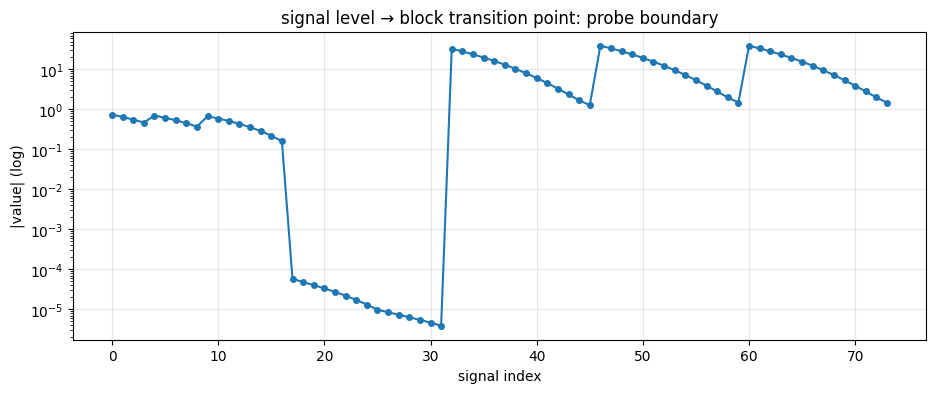

In [25]:
'''
in large scale
ΔΣ ~0.05 - 1 M☉/pc²
wp ~1 - 100 Mpc/h
ξ± ~1e-7 - 1e-4
'''
plt.figure(figsize=(11,4))
plt.semilogy(np.abs(sig), 'o-', ms=4)
plt.xlabel('signal index'); plt.ylabel('|value| (log)')
plt.title('signal level → block transition point: probe boundary')
plt.grid(alpha=.3); plt.savefig('signal_blocks.png', dpi=130)

guess = np.where(np.abs(sig) > 1, 'wp',
         np.where(np.abs(sig) > 1e-2, 'ds', 'xi'))
for p in ['ds','wp','xi']:
    print(f"{p}: {np.sum(guess==p)} points")

In [26]:
cosmo_lit = make_cosmo(omb, omc, 100*h_lit, ns_, s8)
m_mine = theory_vector(cosmo_lit, X=[1,1,1], b=b_lit)    # X=1

lit_wp = sig[-42:]; my_wp = m_mine[-42:]
print(np.round(my_wp/lit_wp, 3))

n_ds_lit = np.sum(guess=='ds'); n_wp_lit = np.sum(guess=='wp')
print(f"reference: ds={n_ds_lit}, wp={n_wp_lit} v.s. mine: ds={n_ds}, wp={n_wp}")
if n_ds_lit == n_ds and n_wp_lit == n_wp:
    sig_ds = sig[guess=='ds']; sig_wp = sig[guess=='wp']
    my_ds = m_mine[:n_ds];    my_wp = m_mine[-n_wp:]
    print("ds ratio (mine/lit):", np.round(my_ds/sig_ds, 3))
    print("wp ratio (mine/lit):", np.round(my_wp/sig_wp, 3))
else:
    print("have different number of points → scale cut different (需按 ANG 對位後再比?)")

R_fac, E_fac in  0 : 0.9787937385975323 1.0440089434955542
R_fac, E_fac in  1 : 0.9617138447051136 1.0801977235015372
R_fac, E_fac in  2 : 0.9549887742448859 1.0941516479251476
[0.999 0.999 0.999 0.998 0.998 0.997 0.995 0.994 0.991 0.988 0.985 0.98
 0.972 0.961 0.999 0.999 0.999 0.998 0.998 0.997 0.995 0.994 0.992 0.989
 0.986 0.982 0.975 0.963 0.999 0.999 0.999 0.998 0.998 0.997 0.996 0.994
 0.992 0.989 0.986 0.982 0.976 0.964]
reference: ds=17, wp=42 v.s. mine: ds=17, wp=42
ds ratio (mine/lit): [1.032 1.032 1.032 1.031 0.999 1.001 1.002 1.001 0.998 0.968 0.971 0.973
 0.972 0.968 0.961 0.952 0.944]
wp ratio (mine/lit): [0.999 0.999 0.999 0.998 0.998 0.997 0.995 0.994 0.991 0.988 0.985 0.98
 0.972 0.961 0.999 0.999 0.999 0.998 0.998 0.997 0.995 0.994 0.992 0.989
 0.986 0.982 0.975 0.963 0.999 0.999 0.999 0.998 0.998 0.997 0.996 0.994
 0.992 0.989 0.986 0.982 0.976 0.964]


In [27]:
cosmo_planck = make_cosmo(0.02237, 0.1200, 67.36, 0.9649, 0.8111)
cosmo_hscY3 = make_cosmo(omb, omc, h_lit*100, ns_, s8)

b_best = [1.86, 2.10, 2.00]   # 0709 minimize 的 b
b_lit_list = b_lit  # reference b

# theory curve
m_planck = theory_vector(cosmo_planck, X=[1,1,1], b=b_best)
m_lit = theory_vector(cosmo_hscY3,  X=[1,1,1], b=b_lit_list)

chi2_planck = (data_vec - m_planck) @ icov @ (data_vec - m_planck)
chi2_lit = (data_vec - m_lit)    @ icov @ (data_vec - m_lit)
print(f"Planck + X=1 + b: chi2 = {chi2_planck:.1f}")
print(f"ref params + ref b: chi2 = {chi2_lit:.1f}")

R_fac, E_fac in  0 : 0.993377482652382 1.0135412083291437
R_fac, E_fac in  1 : 0.9877529659657256 1.024971347717655
R_fac, E_fac in  2 : 0.9854668782816985 1.0294477679874368
R_fac, E_fac in  0 : 0.9787937385975323 1.0440089434955542
R_fac, E_fac in  1 : 0.9617138447051136 1.0801977235015372
R_fac, E_fac in  2 : 0.9549887742448859 1.0941516479251476
Planck + X=1 + b: chi2 = 210.1
ref params + ref b: chi2 = 76.9


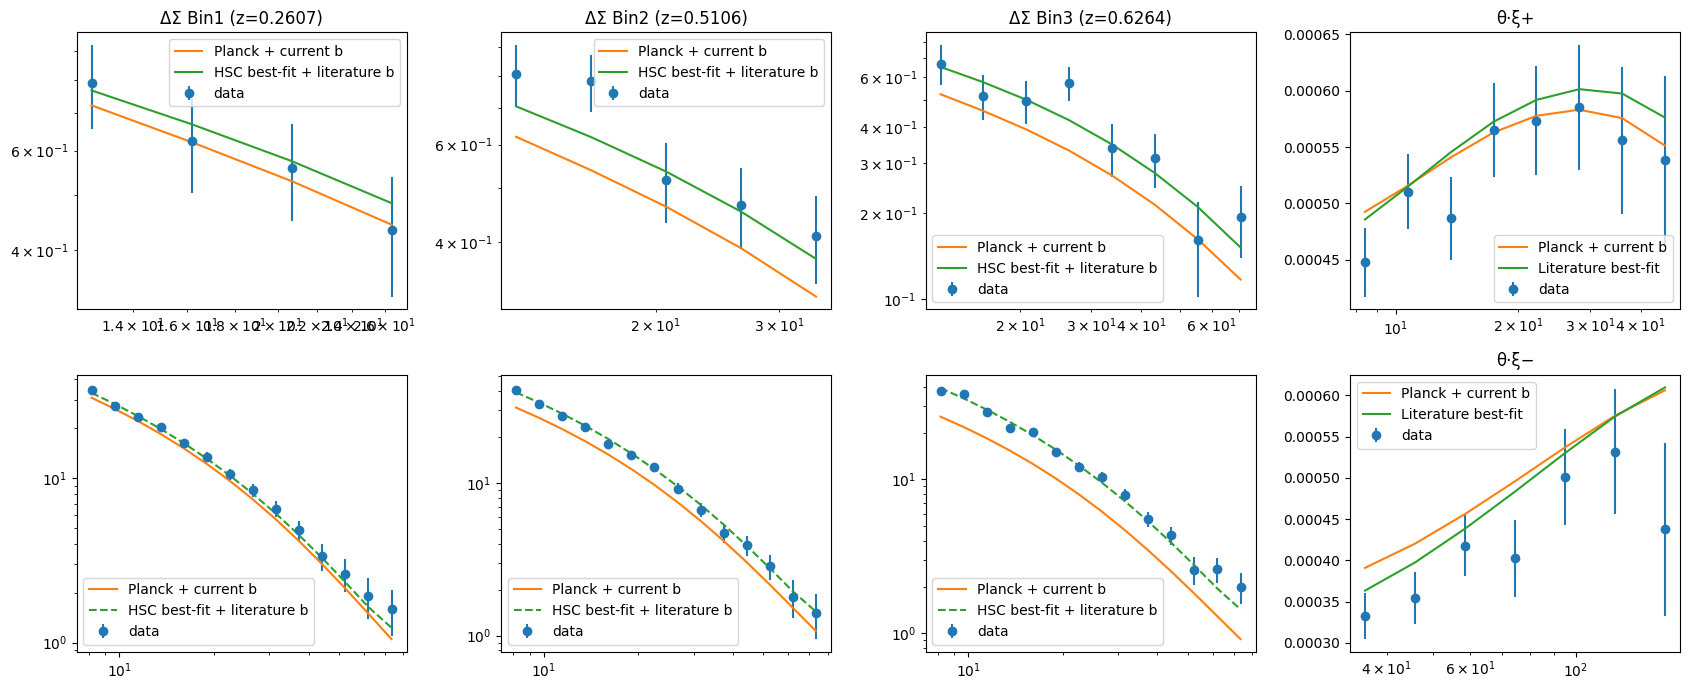

In [34]:
def split(v):
    out, p = {}, 0
    for i in range(3):
        n = ((ds_t['BIN1']==i+1)&ds_cut).sum(); out[f'ds{i+1}'] = v[p:p+n]; p += n
    out['xip'] = v[p:p+n_xip]; p += n_xip
    out['xim'] = v[p:p+n_xim]; p += n_xim
    for i in range(3):
        n = ((wp_t['BIN1']==i+1)&wp_cut).sum(); out[f'wp{i+1}'] = v[p:p+n]; p += n

    return out

D, MP, ML, E = split(data_vec), split(m_planck), split(m_lit),split(err)
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
for i in range(3):
    rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
    ax[0,i].errorbar(rp, D[f'ds{i+1}'], E[f'ds{i+1}'], fmt='o', label='data')
    ax[0,i].loglog(rp, MP[f'ds{i+1}'], '-', label='Planck + current b')
    ax[0,i].loglog(rp, ML[f'ds{i+1}'], '-', label='HSC best-fit + literature b')
    ax[0,i].set_title(f'ΔΣ Bin{i+1} (z={z_l_eff[i]})')
    ax[0,i].legend()
    
    rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
    ax[1,i].errorbar(rw, D[f'wp{i+1}'], E[f'wp{i+1}'],fmt='o', label='data')
    ax[1,i].loglog(rw, MP[f'wp{i+1}'], '-',label='Planck + current b')
    ax[1,i].loglog(rw, ML[f'wp{i+1}'], '--',label='HSC best-fit + literature b')
    ax[1, i].legend()

th = xip_t['ANG'][xip_cut]
ax[0,3].errorbar(th, th*D['xip'], th*E['xip'], fmt='o', label='data')
ax[0,3].semilogx(th, th*MP['xip'], '-', label='Planck + current b')
ax[0,3].semilogx(th, th*ML['xip'], '-', label='Literature best-fit')
ax[0,3].set_title('θ·ξ+')
ax[0,3].legend()

th_m = xim_t['ANG'][xim_cut]
ax[1,3].errorbar(th_m, th_m*D['xim'], th_m*E['xim'], fmt='o', label='data')
ax[1,3].semilogx(th_m, th_m*MP['xim'], '-', label='Planck + current b')
ax[1,3].semilogx(th_m, th_m*ML['xim'], '-', label='Literature best-fit')
ax[1,3].set_title('θ·ξ−')
ax[1,3].legend()
plt.tight_layout(); plt.savefig('theory_vs_data.png', dpi=140)

R_fac, E_fac in  0 : 0.993377482652382 1.0135412083291437
R_fac, E_fac in  1 : 0.9877529659657256 1.024971347717655
R_fac, E_fac in  2 : 0.9854668782816985 1.0294477679874368
R_fac, E_fac in  0 : 0.993377482652382 1.0135412083291437
R_fac, E_fac in  1 : 0.9877529659657256 1.024971347717655
R_fac, E_fac in  2 : 0.9854668782816985 1.0294477679874368
R_fac, E_fac in  0 : 0.993377482652382 1.0135412083291437
R_fac, E_fac in  1 : 0.9877529659657256 1.024971347717655
R_fac, E_fac in  2 : 0.9854668782816985 1.0294477679874368


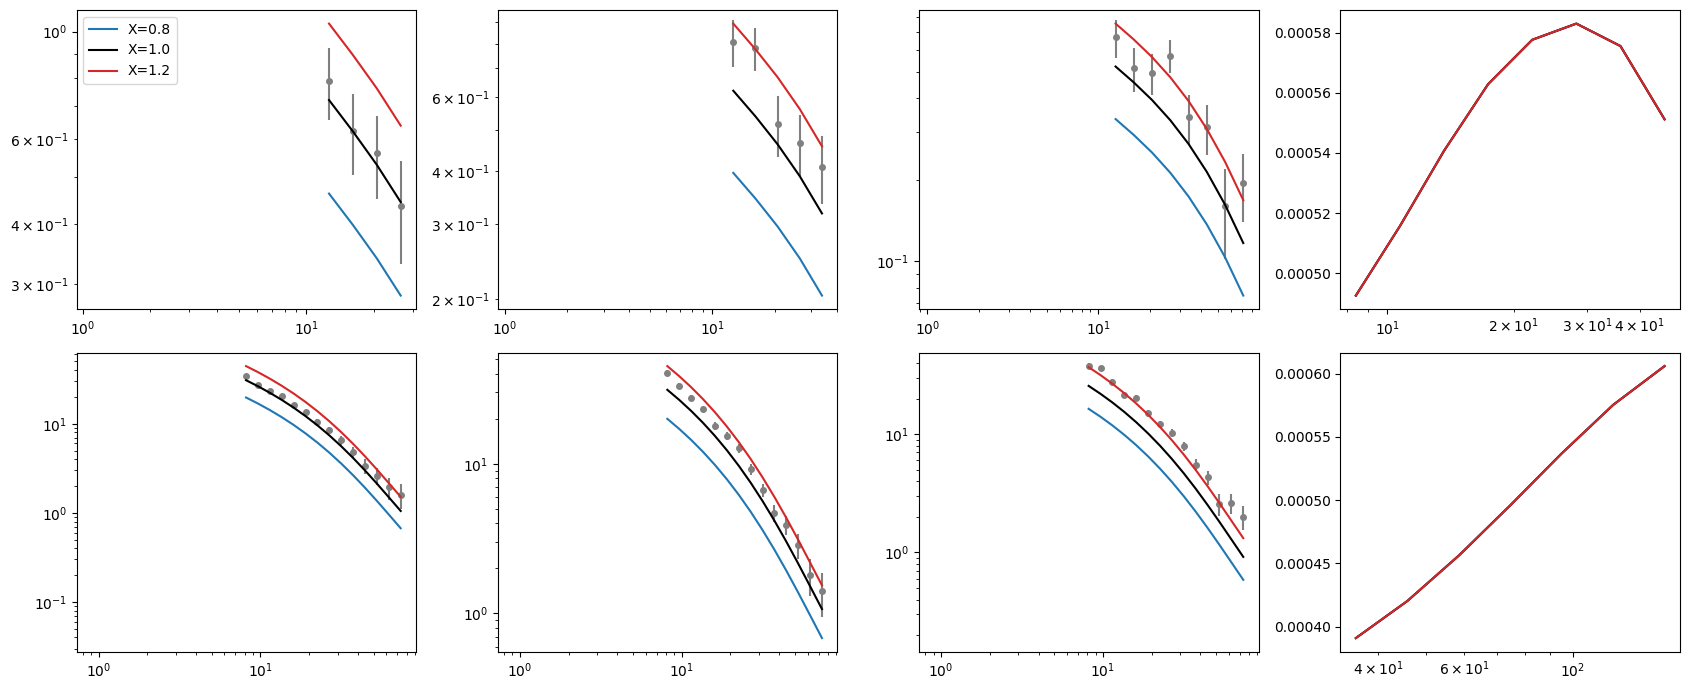

In [32]:
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
for Xv, c in zip([0.8, 1.0, 1.2], ['C0', 'k', 'C3']):
    S = split(theory_vector(cosmo_planck, X=[Xv]*3, b=b_best))
    for i in range(3):
        rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
        rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
        ax[0,i].loglog(rp, S[f'ds{i+1}'], c=c, label=f'X={Xv}')
        ax[1,i].loglog(rw, S[f'wp{i+1}'], c=c)
    ax[0,3].semilogx(th, th*S['xip'], c=c)
    ax[1,3].semilogx(th_m, th_m*S['xim'], c=c)

for i in range(3):   # 疊上 data
    rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
    rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
    ax[0,i].errorbar(rp, D[f'ds{i+1}'], E[f'ds{i+1}'], fmt='o', ms=4, c='gray', zorder=0)
    ax[1,i].errorbar(rw, D[f'wp{i+1}'], E[f'wp{i+1}'], fmt='o', ms=4, c='gray', zorder=0)
ax[0,0].legend(); plt.tight_layout(); plt.savefig('X_scan.png', dpi=140)

pull: mean=1.62, std=2.13
Planck + current b:
  ds  : sum(pull²) =    31.5  (N=17)
avg of each point:  1.8531210479783398
  xip : sum(pull²) =     4.5  (N=8)
avg of each point:  0.5672309840426634
  xim : sum(pull²) =    17.2  (N=7)
avg of each point:  2.453729762678736
  wp  : sum(pull²) =   475.8  (N=42)
avg of each point:  11.329624225551134
HSC best-fit + literature b:
  ds  : sum(pull²) =    10.4  (N=17)
avg of each point:  0.6138488418881457
  xip : sum(pull²) =     5.1  (N=8)
avg of each point:  0.6361028003203869
  xim : sum(pull²) =     9.7  (N=7)
avg of each point:  1.3831649491222164
  wp  : sum(pull²) =    22.7  (N=42)
avg of each point:  0.5409037185711267


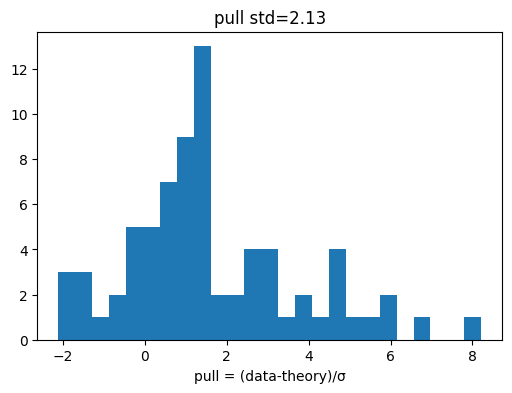

In [33]:
res  = data_vec - m_planck
pull = res / err
print("pull: mean=%.2f, std=%.2f"  % (pull.mean(), pull.std()))

blocks = {'ds': slice(0, n_ds), 'xip': slice(n_ds, n_ds+n_xip),
          'xim': slice(n_ds+n_xip, n_ds+n_xip+n_xim),
          'wp': slice(n_ds+n_xip+n_xim, None)}

plt.figure(figsize=(6,4)); plt.hist(pull, bins=25)
plt.xlabel('pull = (data-theory)/σ'); plt.title(f'pull std={pull.std():.2f}')
plt.savefig('pull_hist.png', dpi=140)

for label, model in [("Planck + current b:", m_planck),("HSC best-fit + literature b:", m_lit)]:
    pull_model = (data_vec - model) / err
    print(label)

    for name, sl in blocks.items():
        print(f"  {name:4s}: sum(pull²) = {np.sum(pull_model[sl]**2):7.1f}  (N={len(pull_model[sl])})")
        print("avg of each point: ", np.sum(pull_model[sl]**2)/len(pull_model[sl]))